### Imports

In [1]:
import random
import warnings

import torch

from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.utils.plotting_utils import visualise_spikes

warnings.filterwarnings('ignore', category=UserWarning)

### Constants

In [2]:
DATASET = DatasetType.AUDIOMNIST
FILTERBANK = FilterbankType.MEL

### Visualise spikes

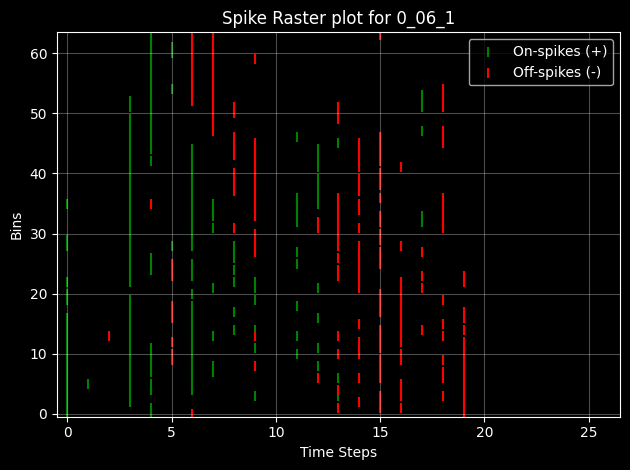

In [3]:
all_files = DATASET.get_spike_dir(FILTERBANK).rglob('*.pt')
random_file = random.choice(list(all_files))
file_name = random_file.stem
spikes = torch.load(random_file)
visualise_spikes(file_name, spikes)

In [4]:
from collections import defaultdict
import numpy as np

class_densities = defaultdict(list)

for spike_file in DATASET.get_spike_dir(FILTERBANK).rglob('*.pt'):
    class_id = int(spike_file.stem.split('_')[0])
    spikes = torch.load(spike_file)  # [T, 1, n_bins]
    T, _, n_bins = spikes.shape
    total_possible = T * n_bins
    count = (spikes != 0).sum().item()
    class_densities[class_id].append(count / total_possible * 100)

for cls in sorted(class_densities):
    d = class_densities[cls]
    print(f"class {cls}: {np.mean(d):.1f}% ± {np.std(d):.1f}%  (n={len(d)})")

all_d = [v for vs in class_densities.values() for v in vs]
print(f"\noverall: {np.mean(all_d):.1f}% ± {np.std(all_d):.1f}%")

class 0: 17.9% ± 3.4%  (n=3000)
class 1: 15.5% ± 3.3%  (n=3000)
class 2: 16.1% ± 2.8%  (n=3000)
class 3: 17.7% ± 3.2%  (n=3000)
class 4: 16.2% ± 3.0%  (n=3000)
class 5: 18.8% ± 3.1%  (n=3000)
class 6: 23.8% ± 3.8%  (n=3000)
class 7: 20.6% ± 3.9%  (n=3000)
class 8: 21.9% ± 3.9%  (n=3000)
class 9: 16.4% ± 3.1%  (n=3000)

overall: 18.5% ± 4.3%
